# Phase II Follow-up AI literacy questionnaire

In [1]:
import importlib
import pandas as pd
import numpy as np
import re
from pathlib import Path

import functions
import functions_Network
importlib.reload(functions)
importlib.reload(functions_Network)
from functions import *
from functions_Network import *
from phase_2_functions import *

In [2]:
df_analysis_phase_I = pd.read_csv("datasets/df_analysis_phase_I.csv")
followup_1111 = pd.read_csv("datasets/AI_Lit_follow_1111.csv")

df_pre, meta = prepare_dataset("datasets/AI_Lit_Que_1111.csv", "datasets/AI_Lit_Que_1204.csv")

# EFA for AI literacy
ai_efa_items = [
    "ai_concept_data_bias_scored_num",
    "ai_concept_blackbox_scored_num",
    "ai_concept_input_variation_scored_num",
    "ai_concept_prompt_wording_scored_num",
    "ai_concept_social_ethics_scored_num",
    "ai_ability_training_data_scored_num",
    "ai_ability_explainability_scored_num",
    "ai_ability_input_sensitivity_scored_num",
    "ai_ability_prompting_scored_num",
    "ai_ability_social_ethics_scored_num",
]
# Use EFA AI literacy factors 1,2 in Pre
df_ai_pre = df_pre.copy()
diag_combined, kmo_items_combined = efa_diagnostics(df_ai_pre, "Combined", ai_efa_items)
fa_combined, d_combined, loadings_combined, variance_combined = fit_efa(
    df=df_ai_pre,
    sample="Combined",
    items=ai_efa_items,
    n_factors=2,
    rotation="oblimin"
)


merged_df = merge_and_score_followup_ai(
    baseline_df=df_analysis_phase_I,
    followup_file_1="datasets/AI_Lit_follow_1111.csv",
    followup_file_2="datasets/AI_Lit_follow_1204.csv",
    ai_fa=fa_combined,
    ai_efa_items=ai_efa_items,
    baseline_id_col="id",
    followup_id_col="Q00_Identification",
    functions_file="functions.py"
)

merged_df.to_csv("datasets/df_analysis_phase_II.csv", index=False)

# 1. Simple Statistical Tests

If post-intervention data is higher AI literacy than pre-intervention. (One-tailed test)
$$
H_0: \text{AI literacy}_{post} = \text{AI literacy}_{pre}\\
H_a: \text{AI literacy}_{post} > \text{AI literacy}_{pre}
$$

In [3]:
run_ai_pre_post_tests(merged_df)

,mean_change_post_minus_pre,wilcoxon_p,cohens_dz,wilcoxon_p_adj,wilcoxon_sig_adj
Ai_understanding,0.190244,0.022986,0.293587,0.045972,True
Ai_confidence,0.058537,0.218122,0.121928,0.218122,False


- After multiple testing correction, only Ai_Conceptual_Score after intervention is significantly higher.

# 2. Rebuild Network analysis

## New network between SES, Mediators, and AI literacy scores (pre and post)

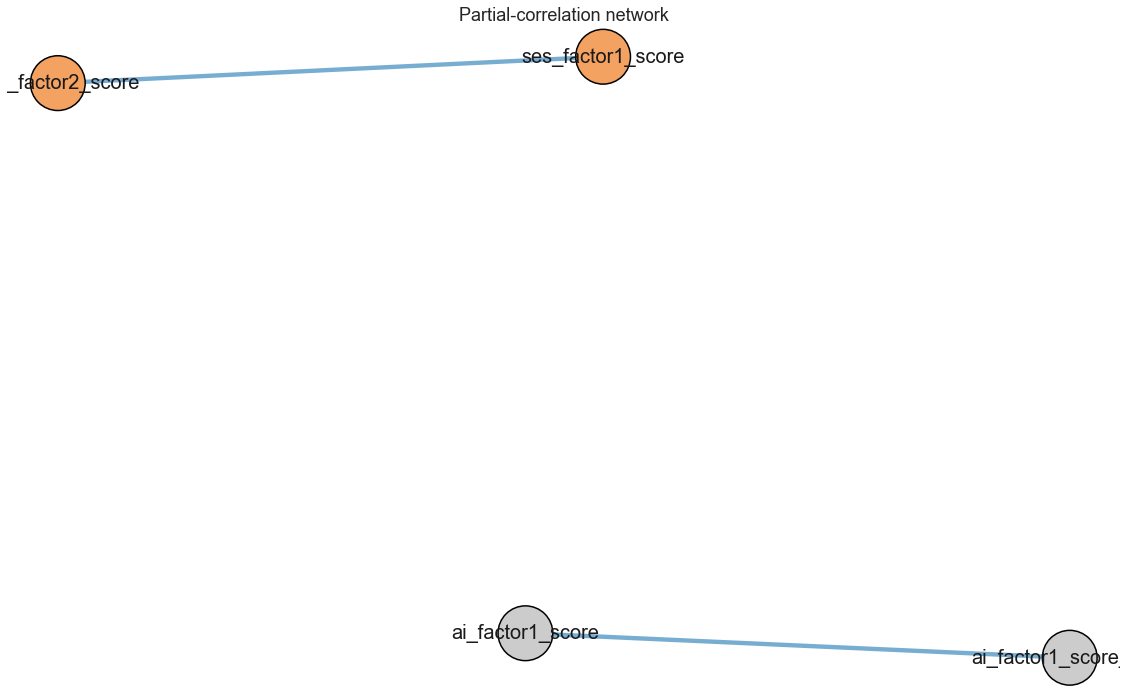

In [4]:
two_wave_res = run_two_wave_ai_network(
    merged_df,
    alpha=0.05,
    adjust_method="fdr_bh",
    min_abs_r=0.0,
    node_groups=node_groups_two_wave
)

plot_network_graph(two_wave_res["graph"], layout="spring", figsize=(16, 10))

## Delta-AI literacy scores (post - pre)

Rebuilds the network with SES + mediators + Change of AI LIteracy 1 and AI literacy 2.

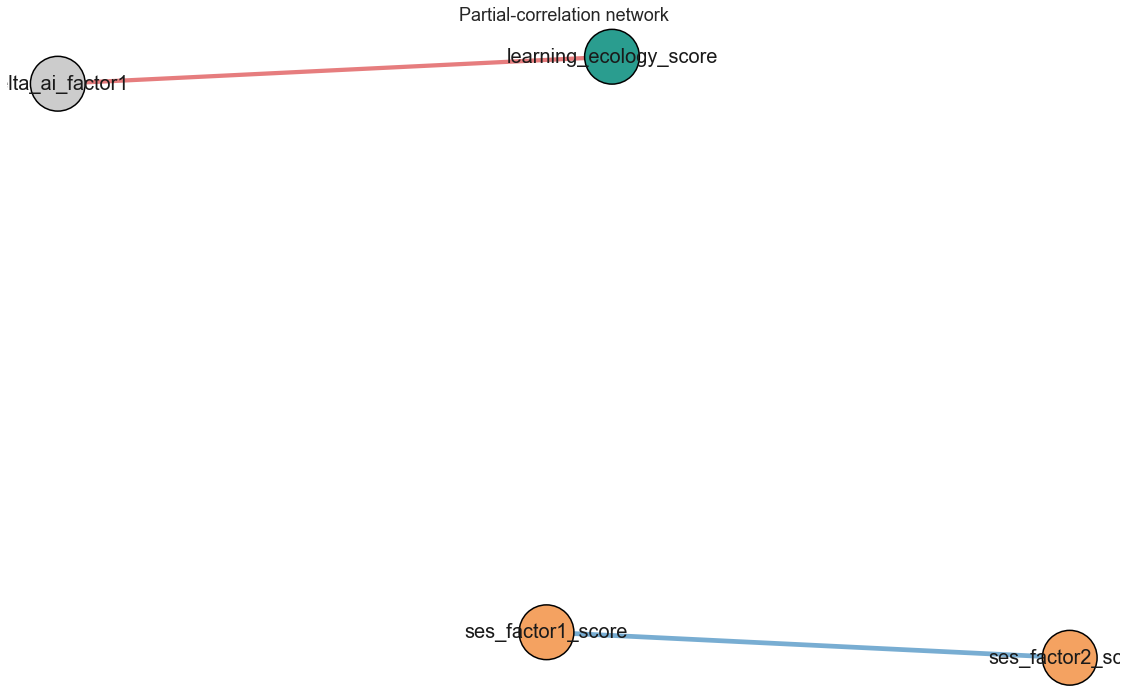

In [6]:
change_res = run_change_score_ai_network(
    merged_df,
    alpha=0.05,
    adjust_method="fdr_bh",
    min_abs_r=0.0,
    node_groups=node_groups_change
)

plot_network_graph(change_res["graph"], layout="spring", figsize=(16, 10))